<a href="https://www.kaggle.com/code/omborse771924/amazon-product-sales-data-aalysis-91-07-accuracy?scriptVersionId=339112046" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/amazon-product-sales-data-42k-items-2025/amazon_sales_data_uncleaned.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/srisyra02/amazon-product-sales-data-42k-items-2025/amazon_sales_data_uncleaned.csv')

In [3]:
df.head()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14


In [4]:
df.info

<bound method DataFrame.info of                                                    Title              Rating  \
0      BOYA BOYALINK 2 Wireless Lavalier Microphone f...  4.6 out of 5 stars   
1      LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...  4.3 out of 5 stars   
2      DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...  4.6 out of 5 stars   
3      Apple AirPods Pro 2 Wireless Earbuds, Active N...  4.6 out of 5 stars   
4      Apple AirTag 4 Pack. Keep Track of and find Yo...  4.8 out of 5 stars   
...                                                  ...                 ...   
42670  Elgato 4K Pro, Internal Capture Card: 8K60 Pas...  5.0 out of 5 stars   
42671  Arlo Essential Spotlight Camera, Wireless Secu...  4.2 out of 5 stars   
42672  GIGABYTE - AORUS FO32U2-32" QD OLED Gaming Mon...  4.3 out of 5 stars   
42673  Monoprice XLR Male to 1/4-Inch TRS Male Cable ...  4.7 out of 5 stars   
42674  Lorex Fusion 1080p HD Security Camera System w...  4.4 out of 5 stars   

      N

In [5]:
df.tail()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0 out of 5 stars,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,30-08-2025 19:56
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2 out of 5 stars,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,30-08-2025 19:56
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3 out of 5 stars,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,30-08-2025 19:56
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7 out of 5 stars,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,30-08-2025 19:56
42674,Lorex Fusion 1080p HD Security Camera System w...,4.4 out of 5 stars,75,50+ bought in past month,419.99,basic variant price: nan,$499.99,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71wTn+zoSr...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,30-08-2025 19:56


In [6]:
df.describe()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
count,42675,41651,41651,39458,30926,42675,42675,42675,42675,42675,28022,30955,3408,42675,40606,42675
unique,8808,31,4413,59,2576,3466,911,12,2,42,1,298,16,8038,40606,331
top,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.6 out of 5 stars,25,100+ bought in past month,29.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,Add to cart,"Delivery Mon, Sep 1",Small Business,https://m.media-amazon.com/images/I/51Xr76m2WL...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,25-08-2025 11:07
freq,744,6151,626,8801,825,21031,30364,40814,35664,40727,28022,6189,1341,1461,1,180


In [7]:
df.isnull()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,False,False,False,True,True,True,False,False,False
4,False,False,False,False,True,False,False,False,False,False,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
42671,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
42672,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
42673,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [8]:
df.isnull().sum()

Title                           0
Rating                       1024
Number_of_reviews            1024
bought_in_last_month         3217
Current/discounted_price    11749
Price_on_variant                0
Listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
buy_box_availability        14653
delivery_details            11720
sustainability_badges       39267
image_url                       0
product_url                  2069
collected_at                    0
dtype: int64

In [9]:
import pandas as pd
import numpy as np

# Create a copy
data = df.copy()

# ==========================
# Convert Rating to numeric
# ==========================
data['Rating'] = data['Rating'].str.extract(r'(\d+\.?\d*)')[0]
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')

# ==========================
# Fill Numerical Columns
# ==========================

num_cols = [
    'Rating',
    'Number_of_reviews',
    'bought_in_last_month',
    'Current/discounted_price'
]

for col in num_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data[col] = data[col].fillna(data[col].median())

# ==========================
# Fill Categorical Columns
# ==========================

cat_cols = [
    'buy_box_availability',
    'delivery_details'
]

for col in cat_cols:
    if col in data.columns:
        data[col] = data[col].fillna("Unknown")

# ==========================
# Fill URL Column
# ==========================

if 'product_url' in data.columns:
    data['product_url'] = data['product_url'].fillna("Not Available")

# ==========================
# Drop Highly Missing Column
# ==========================

if 'sustainability_badges' in data.columns:
    data.drop(columns=['sustainability_badges'], inplace=True)

# ==========================
# Check Missing Values
# ==========================

print(data.isnull().sum())

Title                           0
Rating                          0
Number_of_reviews               0
bought_in_last_month        42675
Current/discounted_price        0
Price_on_variant                0
Listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
buy_box_availability            0
delivery_details                0
image_url                       0
product_url                     0
collected_at                    0
dtype: int64


In [10]:
df.duplicated().sum()

np.int64(962)

In [11]:
df.columns

Index(['Title', 'Rating', 'Number_of_reviews', 'bought_in_last_month',
       'Current/discounted_price', 'Price_on_variant', 'Listed_price',
       'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability',
       'delivery_details', 'sustainability_badges', 'image_url', 'product_url',
       'collected_at'],
      dtype='object')

## EDA

Dataset Shape
(42675, 16)


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Title                     42675 non-null  object 
 1   Rating                    41651 non-null  float64
 2   Number_of_reviews         41651 non-null  float64
 3   bought_in_last_month      39458 non-null  object 
 4   Current/discounted_price  30926 non-null  float64
 5   Price_on_variant          42675 non-null  object 
 6   Listed_price              12311 non-null  float64
 7   is_best_seller            42675 non-null  object 
 8   is_sponsored              42675 non-null  object 
 9   is_couponed               42675 non-null  object 
 10  buy_box_availability      28022 non-null  object 
 11  delivery_details          30955 non-null  object 
 12  sustainability_badges     3408 non-null   object 
 13  image_url           

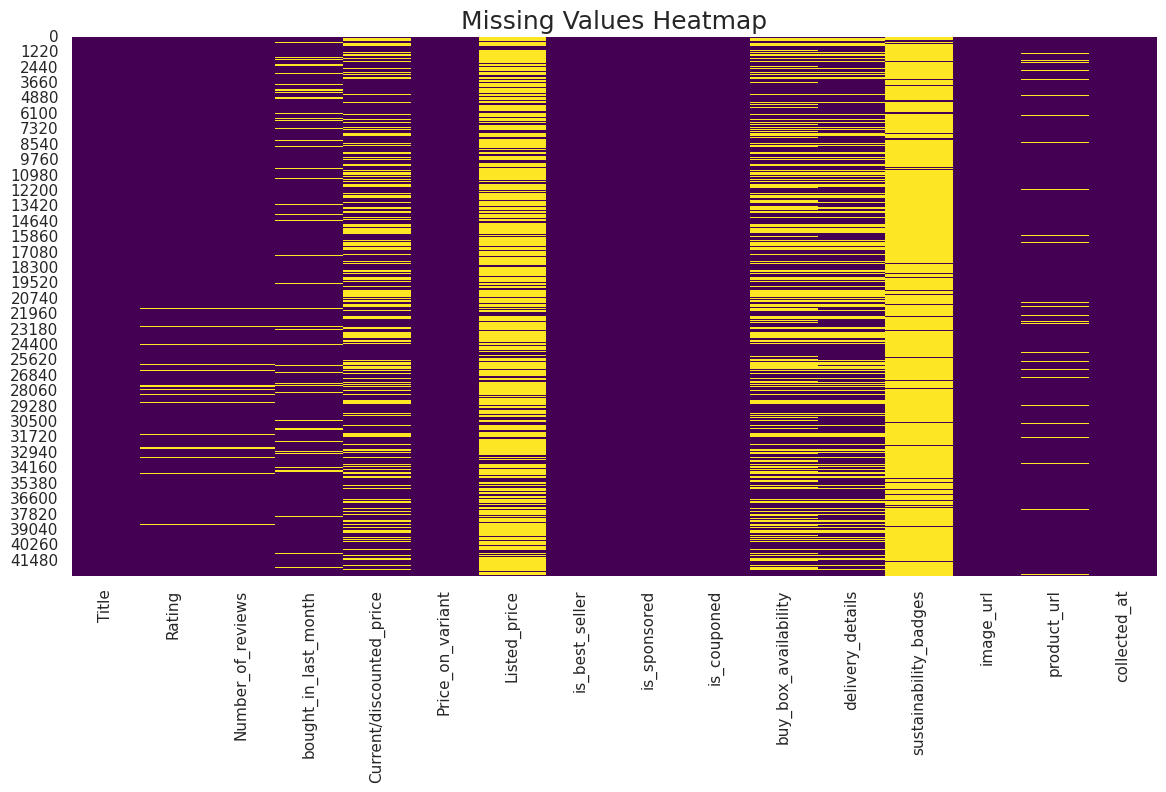

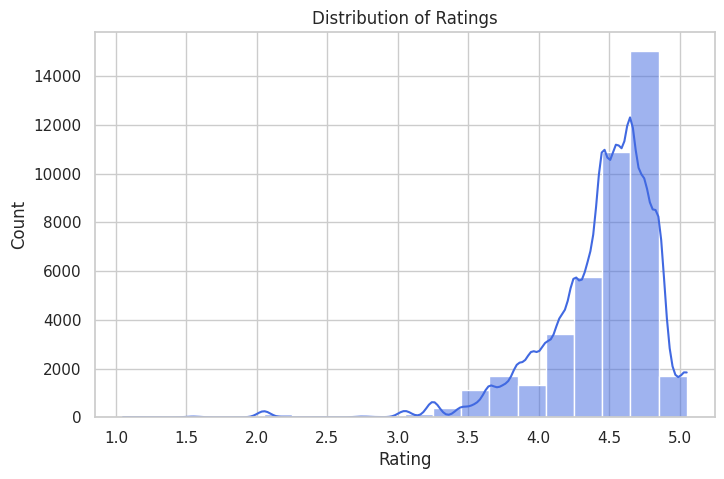

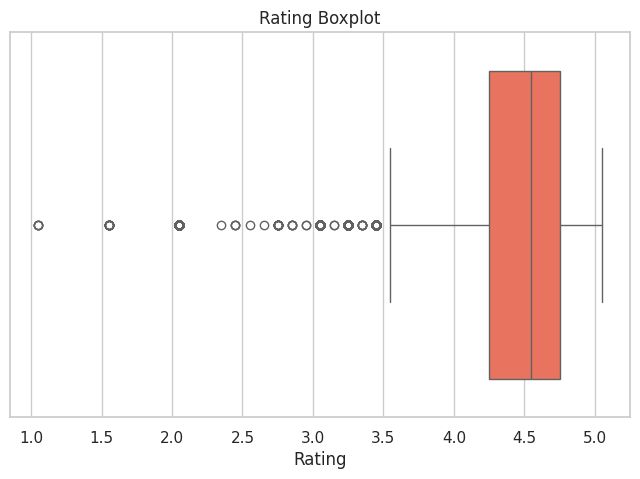

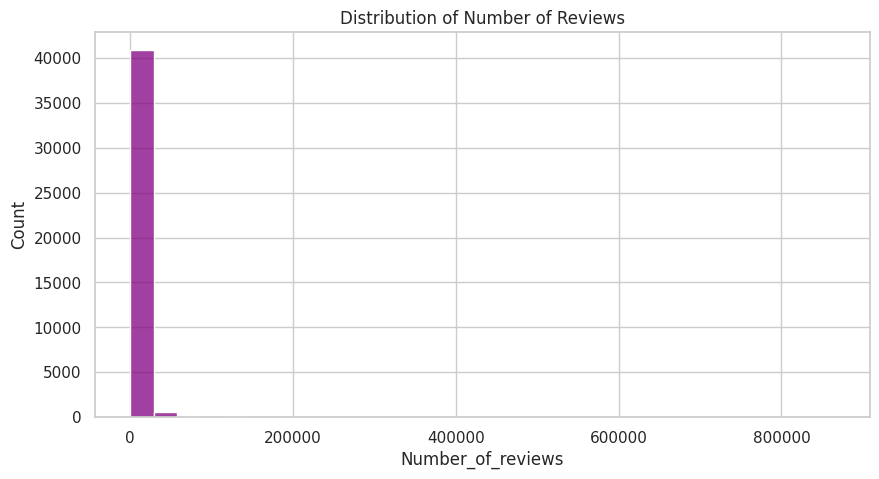

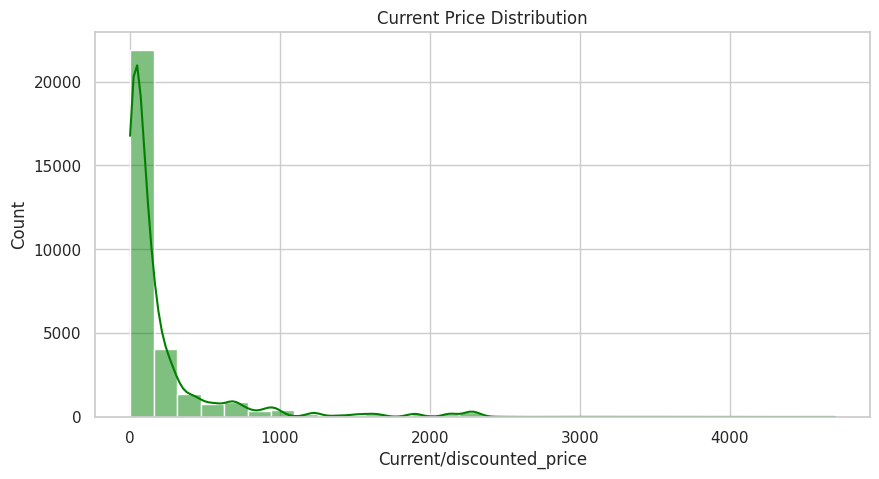

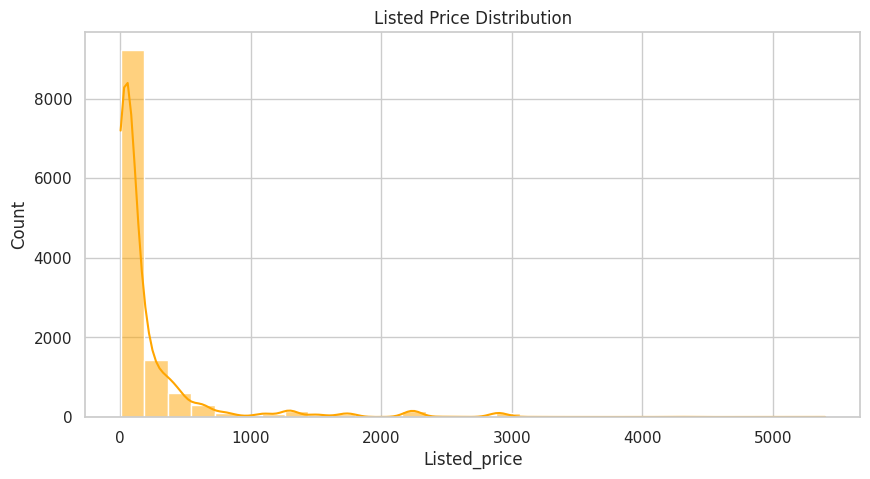

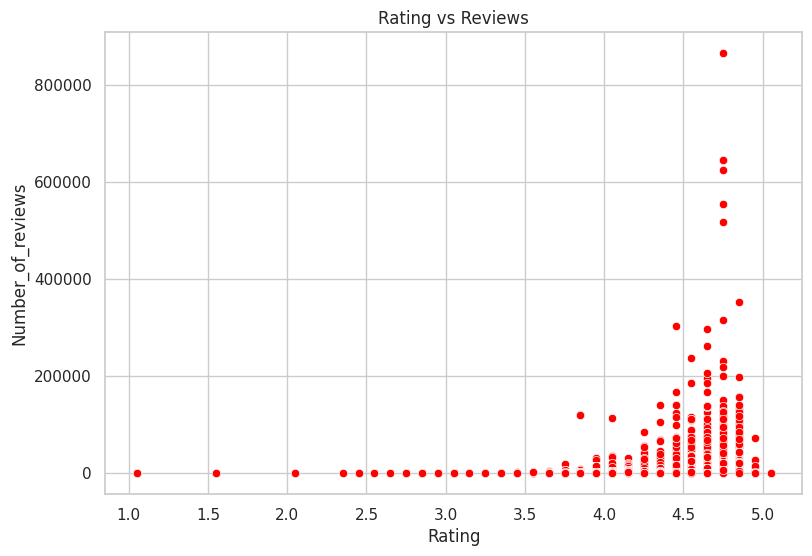

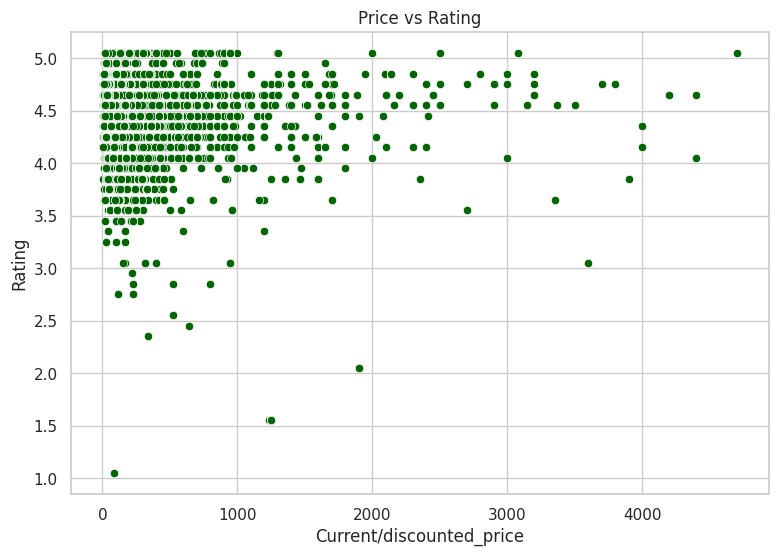

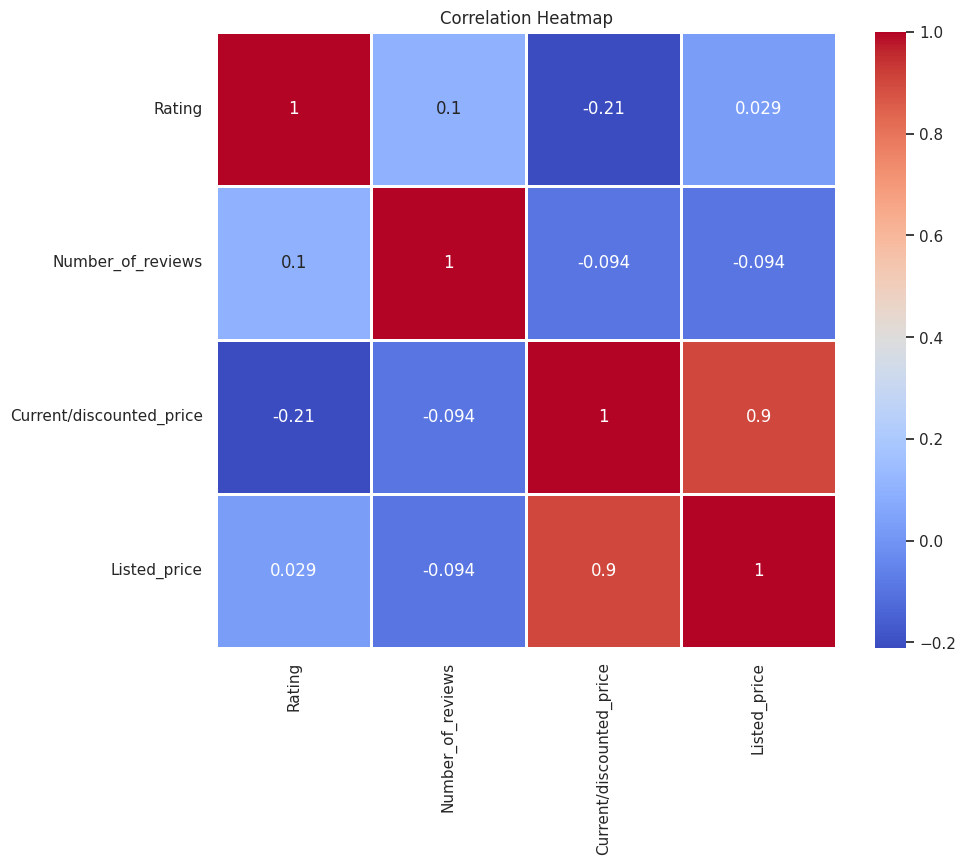

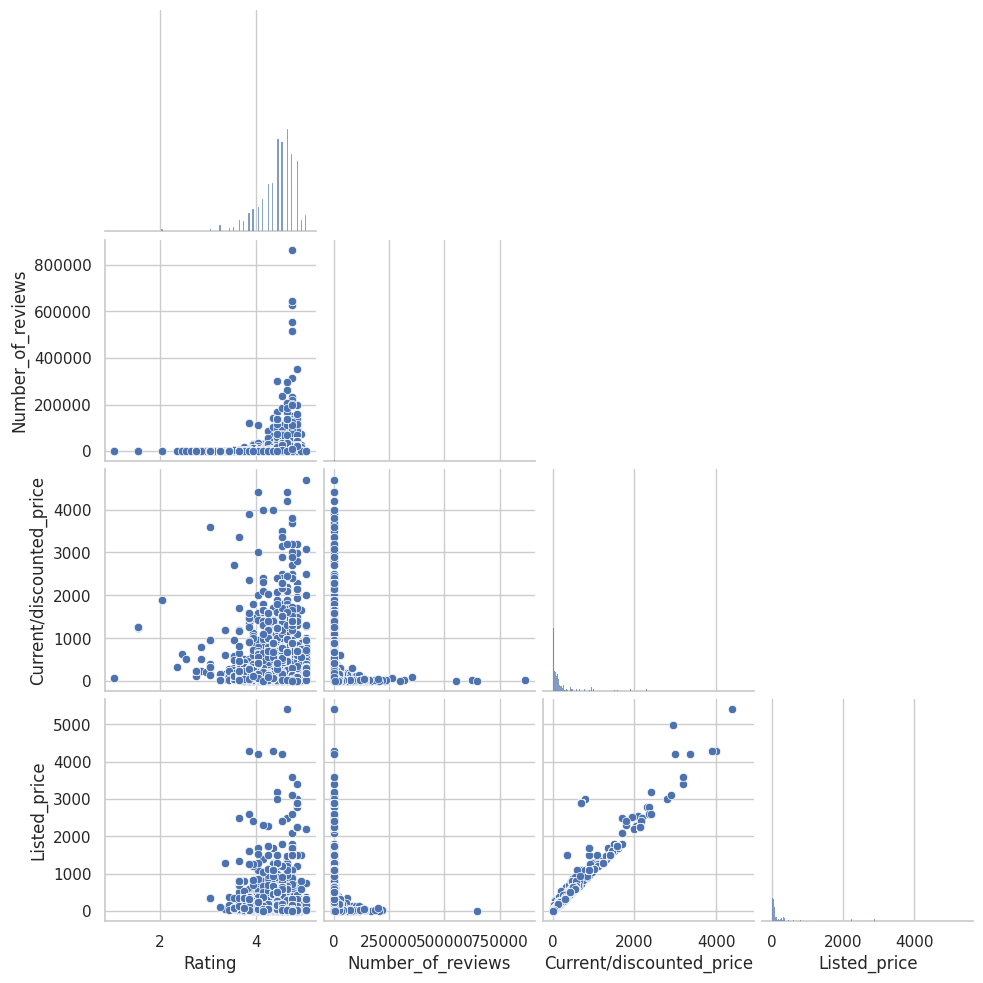

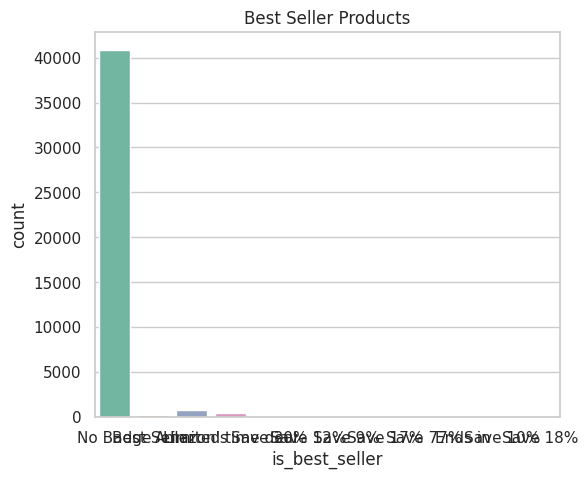

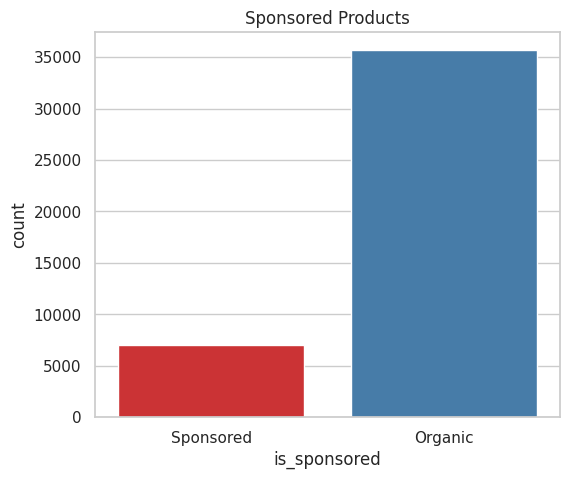

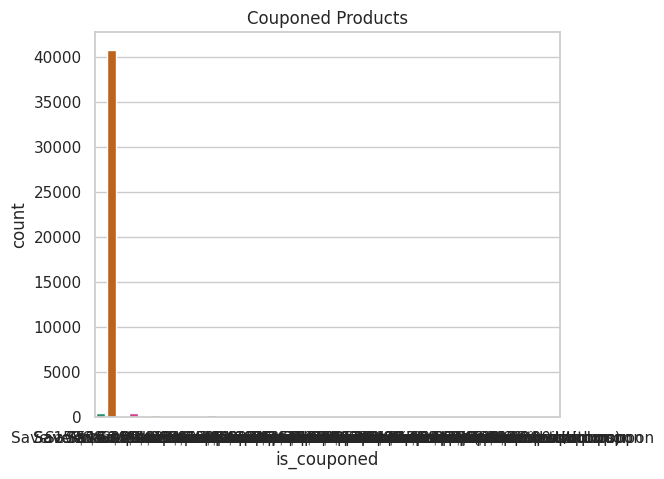

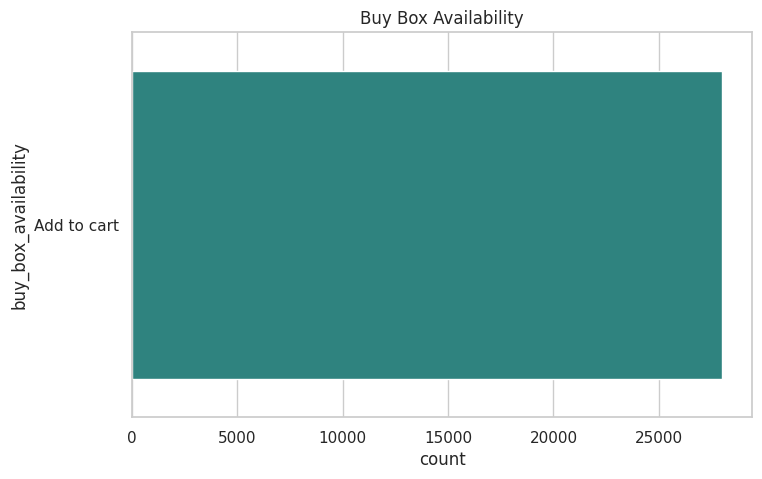

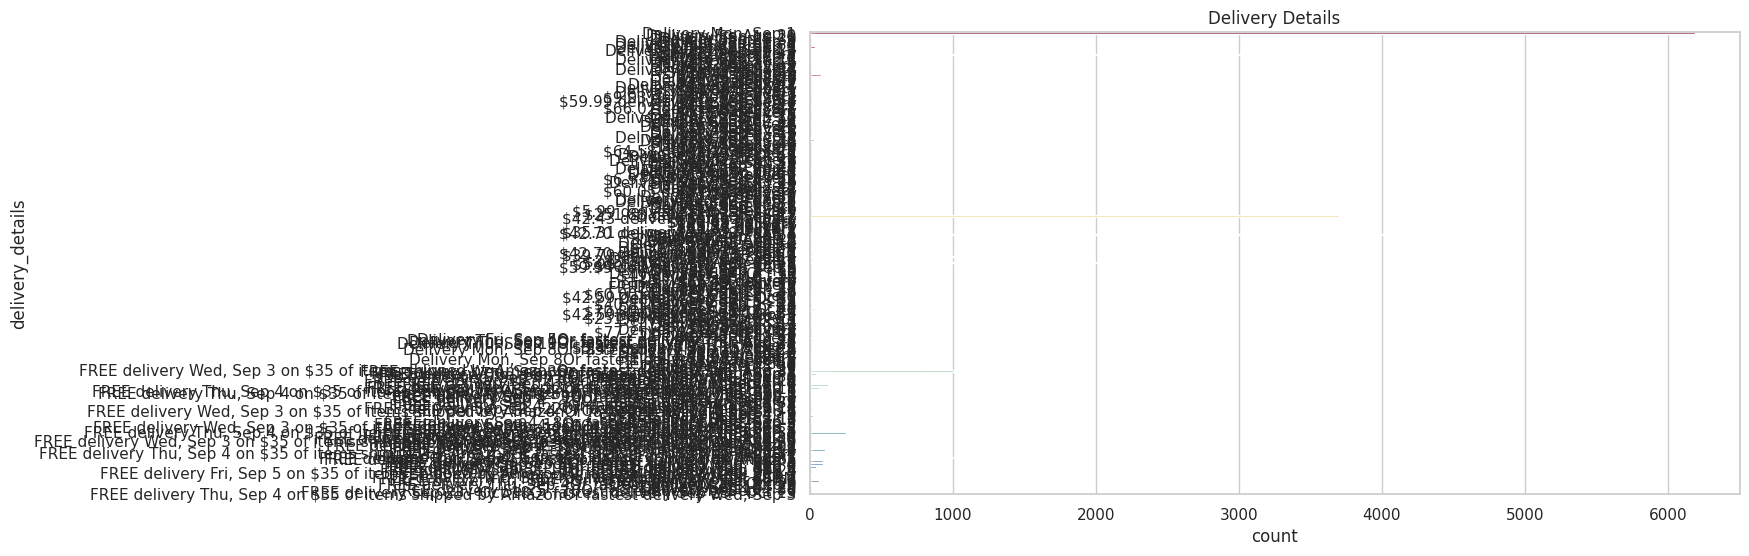

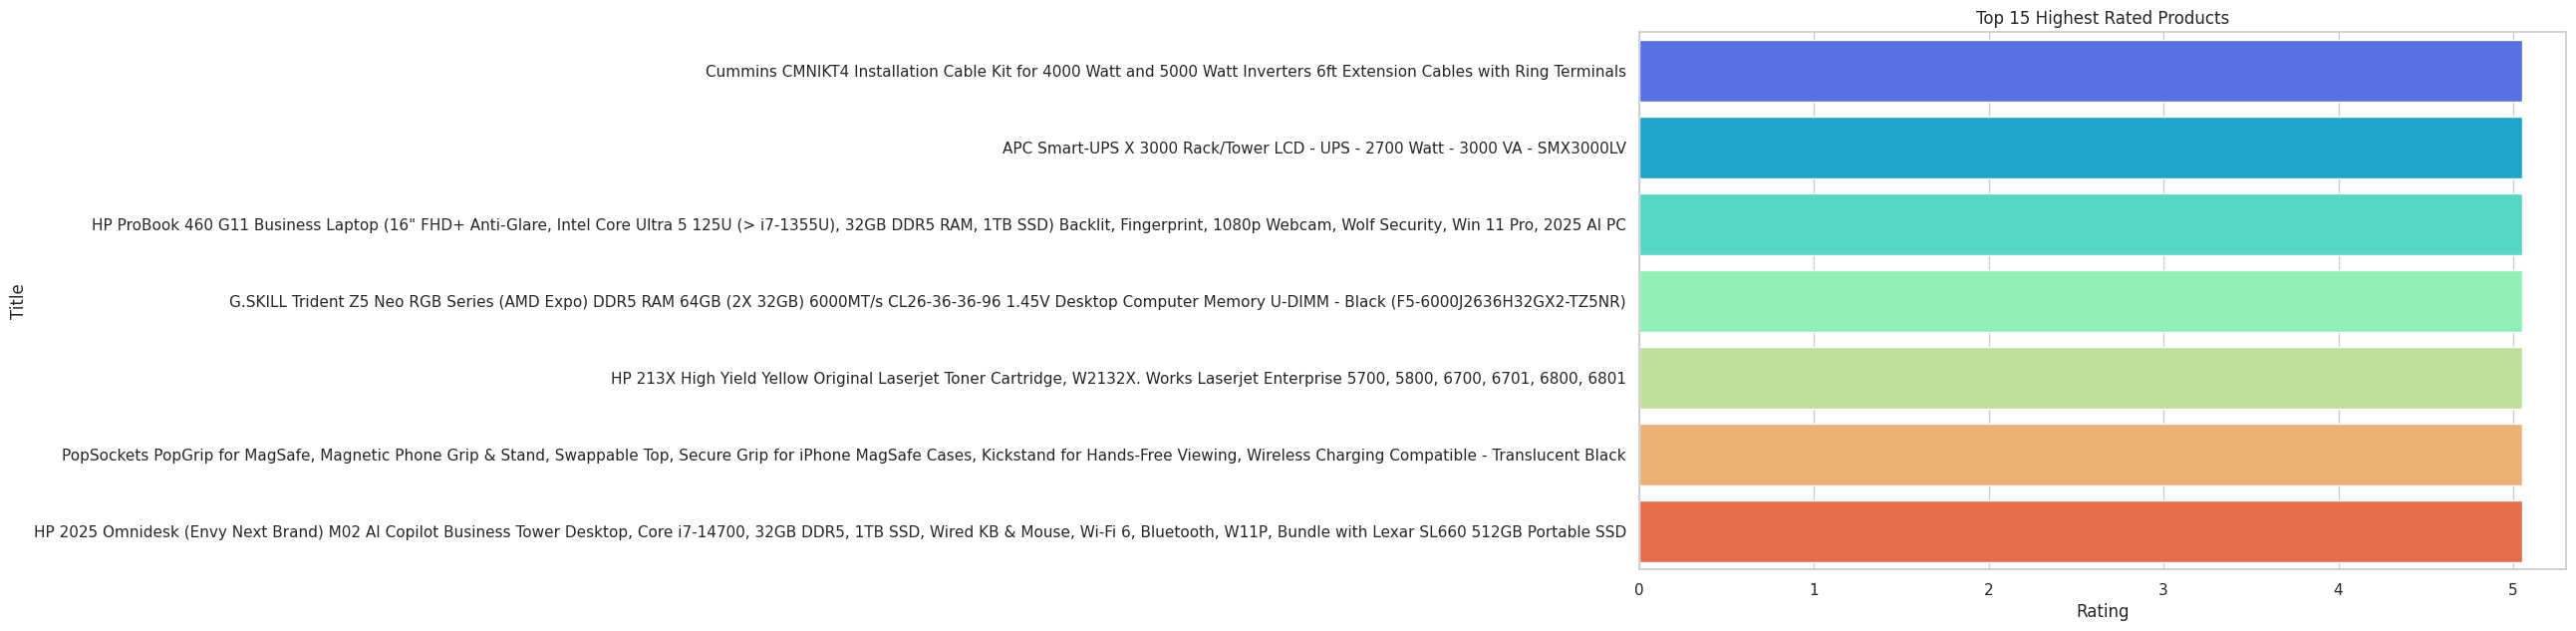

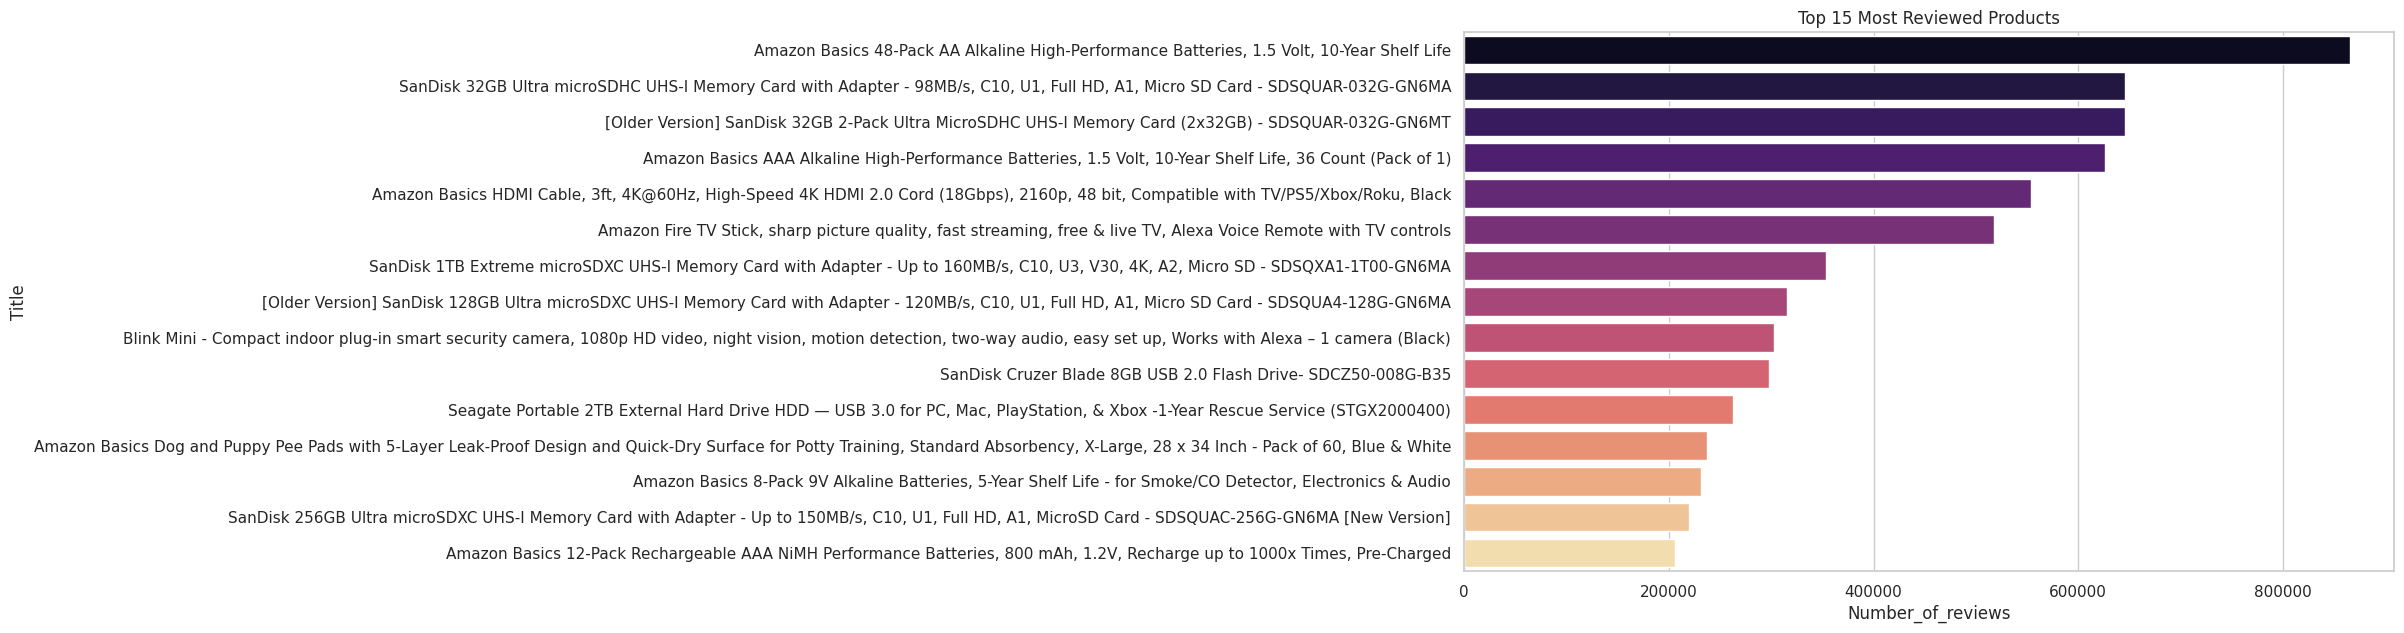

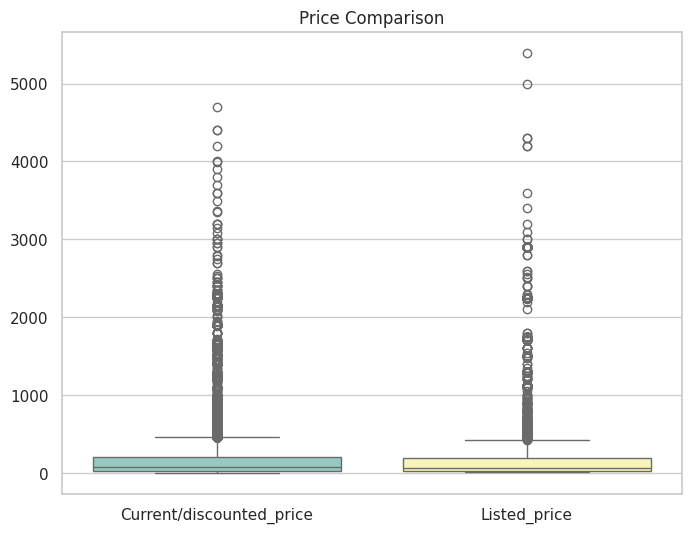

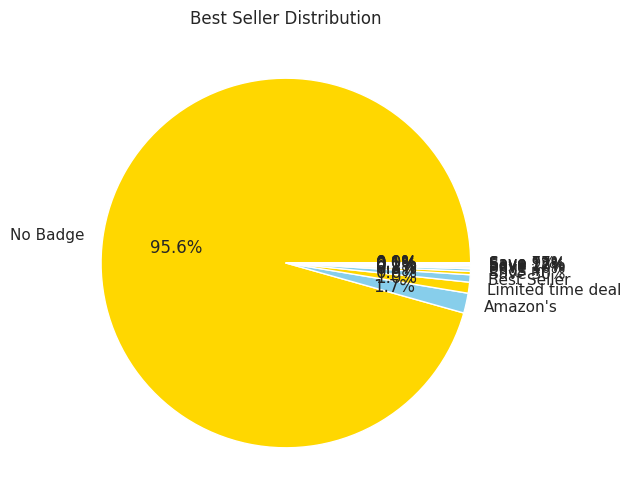

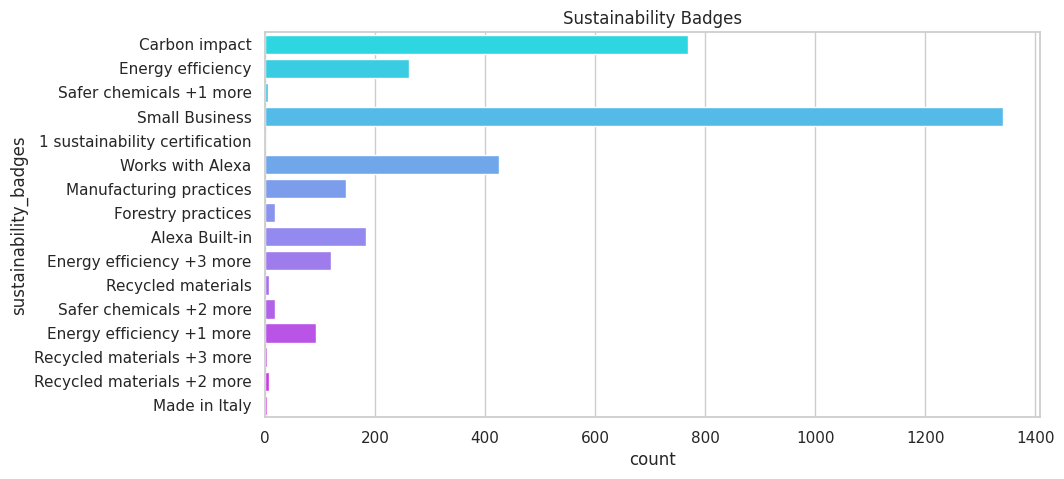

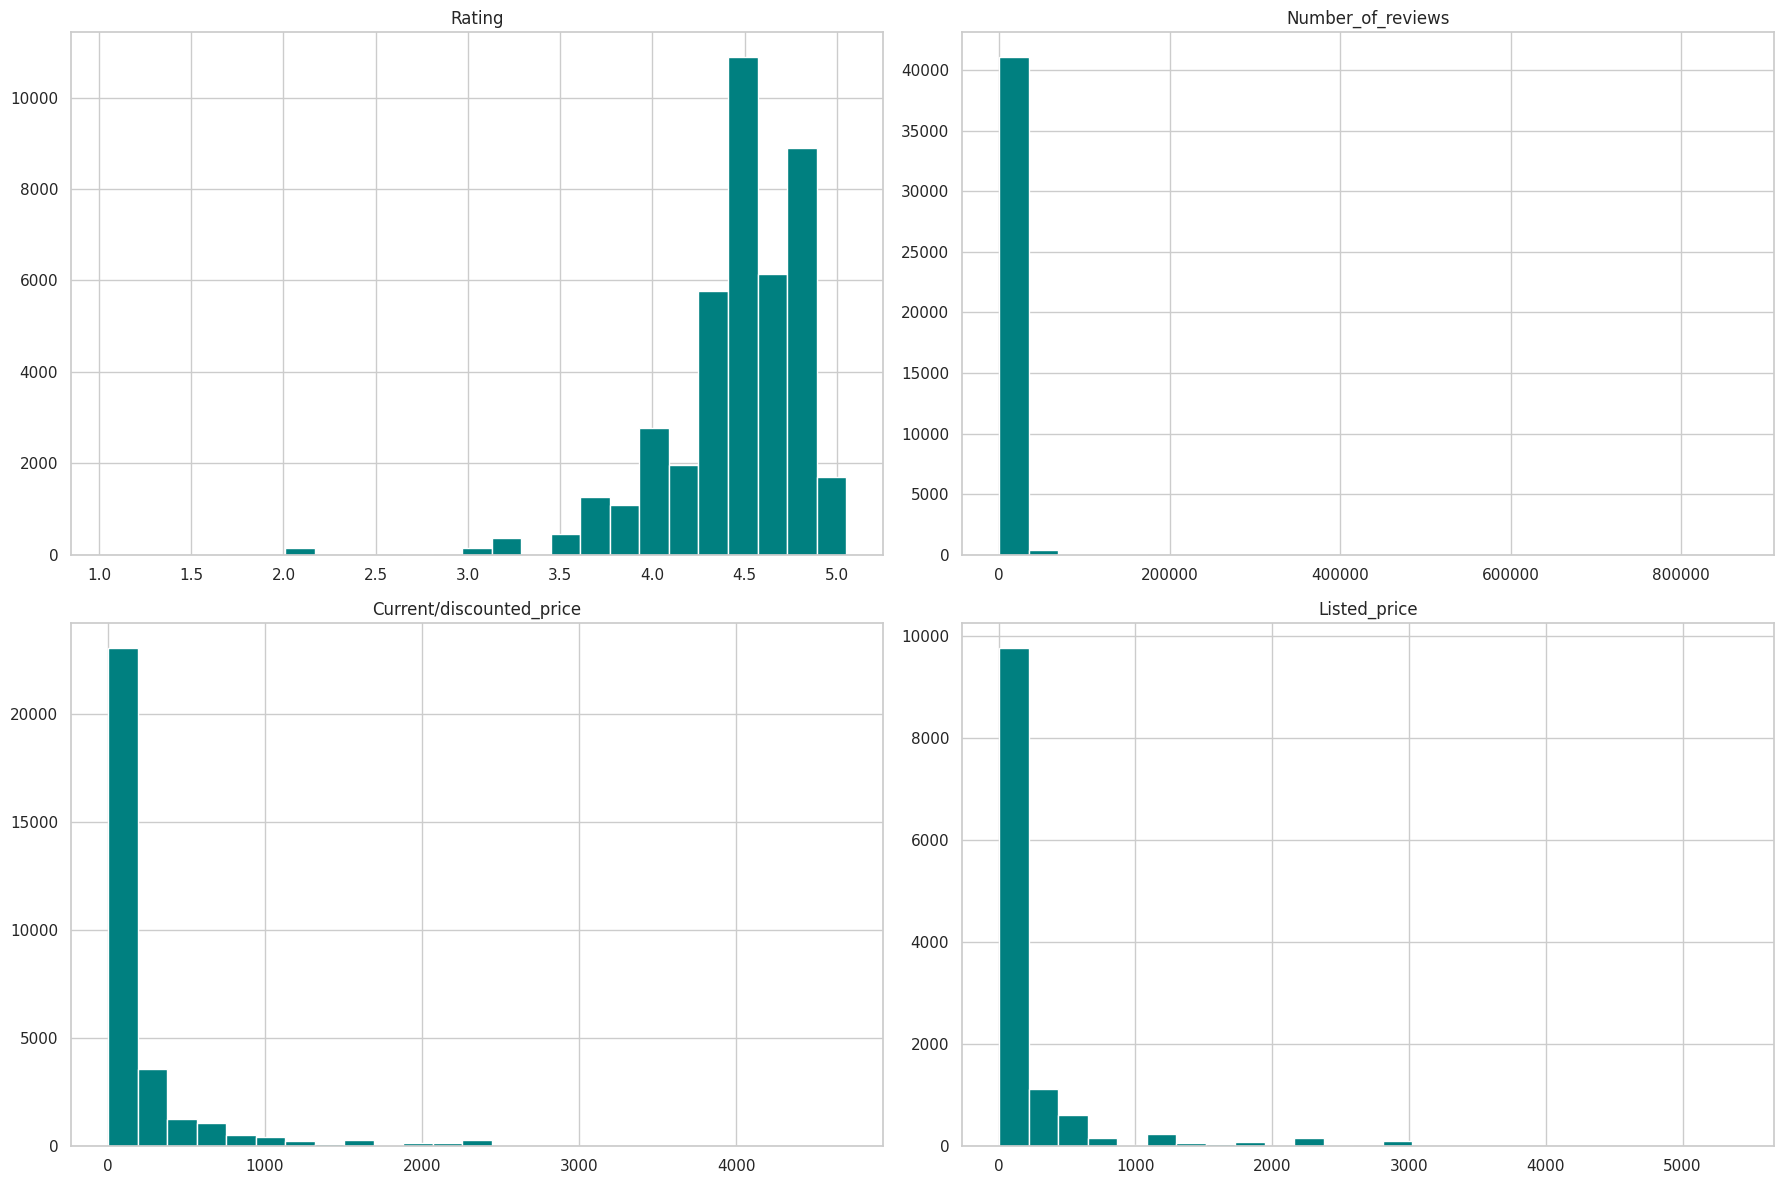

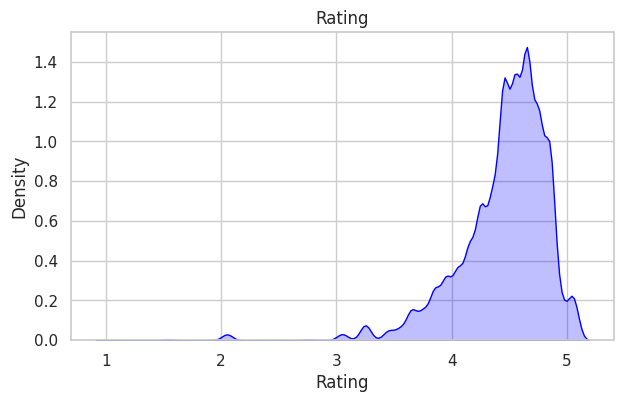

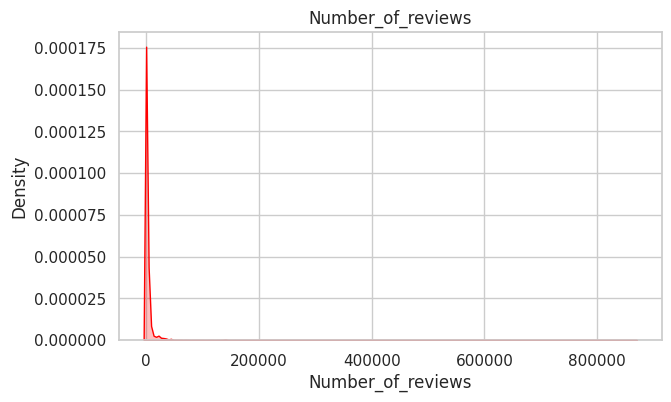

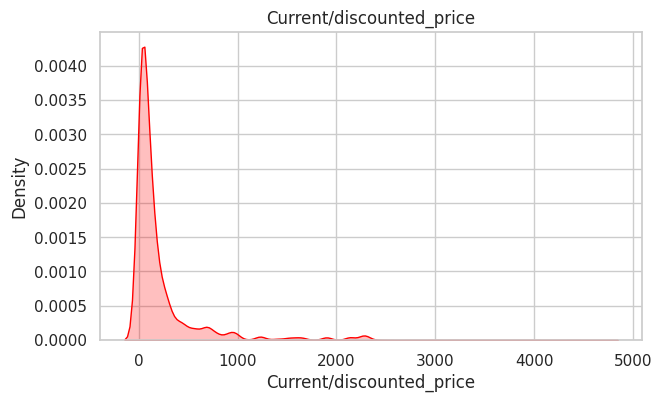

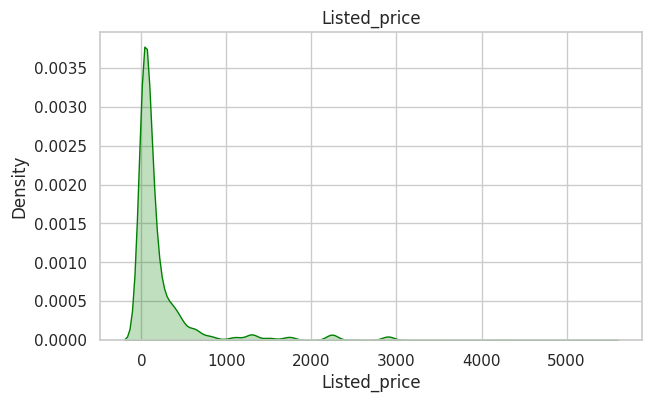

In [12]:
# Part 1: Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Load your dataset here (replace with your actual file path)
# df = pd.read_csv("your_dataset.csv")

# =====================================================================
# --- DATA CLEANING STEP (Fixes the ValueError) ---
# Convert commonly string-formatted columns to actual numbers
# =====================================================================
cols_to_clean = [
    'Rating', 
    'Number_of_reviews', 
    'Current/discounted_price', 
    'Listed_price'
]

for col in cols_to_clean:
    if col in df.columns:
        # Remove commas, currency symbols, and text, then convert to float
        df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Part 2: Dataset Information
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Dataset Info")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("Duplicate Rows")
print("="*60)
print(df.duplicated().sum())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)
print(df.describe(include="all"))

# Part 3: Missing Value Heatmap
plt.figure(figsize=(14,7))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)
plt.title("Missing Values Heatmap",fontsize=18)
plt.show()

# Part 4: Distribution of Ratings
if 'Rating' in df.columns and pd.api.types.is_numeric_dtype(df['Rating']):
    plt.figure(figsize=(8,5))
    sns.histplot(
        df["Rating"],
        bins=20,
        kde=True,
        color="royalblue"
    )
    plt.title("Distribution of Ratings")
    plt.show()

# Part 5: Boxplot of Ratings
if 'Rating' in df.columns and pd.api.types.is_numeric_dtype(df['Rating']):
    plt.figure(figsize=(8,5))
    sns.boxplot(
        x=df["Rating"],
        color="tomato"
    )
    plt.title("Rating Boxplot")
    plt.show()

# Part 6: Distribution of Reviews
if 'Number_of_reviews' in df.columns and pd.api.types.is_numeric_dtype(df['Number_of_reviews']):
    plt.figure(figsize=(10,5))
    sns.histplot(
        df["Number_of_reviews"],
        bins=30,
        color="purple"
    )
    plt.title("Distribution of Number of Reviews")
    plt.show()

# Part 7: Discount Price Distribution
if 'Current/discounted_price' in df.columns and pd.api.types.is_numeric_dtype(df['Current/discounted_price']):
    plt.figure(figsize=(10,5))
    sns.histplot(
        df["Current/discounted_price"],
        bins=30,
        kde=True,
        color="green"
    )
    plt.title("Current Price Distribution")
    plt.show()

# Part 8: Listed Price Distribution
if 'Listed_price' in df.columns and pd.api.types.is_numeric_dtype(df['Listed_price']):
    plt.figure(figsize=(10,5))
    sns.histplot(
        df["Listed_price"],
        bins=30,
        kde=True,
        color="orange"
    )
    plt.title("Listed Price Distribution")
    plt.show()

# Part 9: Scatter Plot
if 'Rating' in df.columns and 'Number_of_reviews' in df.columns:
    plt.figure(figsize=(9,6))
    sns.scatterplot(
        x="Rating",
        y="Number_of_reviews",
        data=df,
        color="red"
    )
    plt.title("Rating vs Reviews")
    plt.show()

# Part 10: Price vs Rating
if 'Current/discounted_price' in df.columns and 'Rating' in df.columns:
    plt.figure(figsize=(9,6))
    sns.scatterplot(
        x="Current/discounted_price",
        y="Rating",
        data=df,
        color="darkgreen"
    )
    plt.title("Price vs Rating")
    plt.show()

# Part 11: Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

if not numeric_df.empty and numeric_df.shape[1] > 1:
    plt.figure(figsize=(10,8))
    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm",
        linewidths=1
    )
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("\n[!] Skipping Correlation Heatmap: Not enough numeric columns found.")

# Part 12: Pairplot
if not numeric_df.empty and numeric_df.shape[1] > 1:
    sns.pairplot(
        numeric_df,
        corner=True,
        palette="husl"
    )
    plt.show()
else:
    print("\n[!] Skipping Pairplot: Not enough numeric columns found.")

# Part 13: Best Seller Count
if 'is_best_seller' in df.columns:
    plt.figure(figsize=(6,5))
    sns.countplot(
        x="is_best_seller",
        data=df,
        palette="Set2"
    )
    plt.title("Best Seller Products")
    plt.show()

# Part 14: Sponsored Products
if 'is_sponsored' in df.columns:
    plt.figure(figsize=(6,5))
    sns.countplot(
        x="is_sponsored",
        data=df,
        palette="Set1"
    )
    plt.title("Sponsored Products")
    plt.show()

# Part 15: Couponed Products
if 'is_couponed' in df.columns:
    plt.figure(figsize=(6,5))
    sns.countplot(
        x="is_couponed",
        data=df,
        palette="Dark2"
    )
    plt.title("Couponed Products")
    plt.show()

# Part 16: Buy Box Availability
if 'buy_box_availability' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(
        y="buy_box_availability",
        data=df,
        palette="viridis"
    )
    plt.title("Buy Box Availability")
    plt.show()

# Part 17: Delivery Details
if 'delivery_details' in df.columns:
    plt.figure(figsize=(12,6))
    sns.countplot(
        y="delivery_details",
        data=df,
        palette="Spectral"
    )
    plt.title("Delivery Details")
    plt.show()

# Part 18: Top 15 Highest Rated Products
if 'Rating' in df.columns and 'Title' in df.columns:
    top = df.sort_values(
        by="Rating",
        ascending=False
    ).head(15)

    plt.figure(figsize=(12,7))
    sns.barplot(
        x="Rating",
        y="Title",
        data=top,
        palette="rainbow"
    )
    plt.title("Top 15 Highest Rated Products")
    plt.show()

# Part 19: Top 15 Most Reviewed Products
if 'Number_of_reviews' in df.columns and 'Title' in df.columns:
    top = df.sort_values(
        by="Number_of_reviews",
        ascending=False
    ).head(15)

    plt.figure(figsize=(12,7))
    sns.barplot(
        x="Number_of_reviews",
        y="Title",
        data=top,
        palette="magma"
    )
    plt.title("Top 15 Most Reviewed Products")
    plt.show()

# Part 20: Price Comparison
if 'Current/discounted_price' in df.columns and 'Listed_price' in df.columns:
    price = df[[
        "Current/discounted_price",
        "Listed_price"
    ]]

    plt.figure(figsize=(8,6))
    sns.boxplot(
        data=price,
        palette="Set3"
    )
    plt.title("Price Comparison")
    plt.show()

# Part 21: Pie Chart
if 'is_best_seller' in df.columns:
    plt.figure(figsize=(6,6))
    df["is_best_seller"].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        colors=["gold","skyblue"]
    )
    plt.ylabel("")
    plt.title("Best Seller Distribution")
    plt.show()

# Part 22: Count of Sustainability Badges
if 'sustainability_badges' in df.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(
        y="sustainability_badges",
        data=df,
        palette="cool"
    )
    plt.title("Sustainability Badges")
    plt.show()

# Part 23: Numerical Features Histograms
num = df.select_dtypes(include=np.number)

if not num.empty:
    num.hist(
        figsize=(18,12),
        bins=25,
        color="teal"
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[!] Skipping Numerical Histograms: No numeric columns found.")

# Part 24: KDE Plots
if not num.empty:
    for col in num.columns:
        # Drop NaNs before KDE plot to avoid matplotlib scaling errors
        col_data = num[col].dropna()
        if len(col_data) > 1:
            plt.figure(figsize=(7,4))
            sns.kdeplot(
                col_data,
                fill=True,
                color=np.random.choice([
                    "red",
                    "green",
                    "blue",
                    "orange",
                    "purple",
                    "brown"
                ])
            )
            plt.title(col)
            plt.show()

## Features Engineering

Training Features Shape: (34140, 14)
Testing Features Shape:  (8535, 14)

Number of distinct classes detected in target: 12

---> LOGISTIC REGRESSION <---
Accuracy Score: 21.16%
ROC AUC Score:  nan

Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.10      0.03       149
           1       0.03      0.20      0.05        55
           2       0.01      1.00      0.02        19
           3       0.03      0.60      0.06        82
           4       0.98      0.21      0.34      8163
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        12
           9       0.02      1.00      0.04        25
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         3

    accuracy                           0.21      8535
   macro avg       0

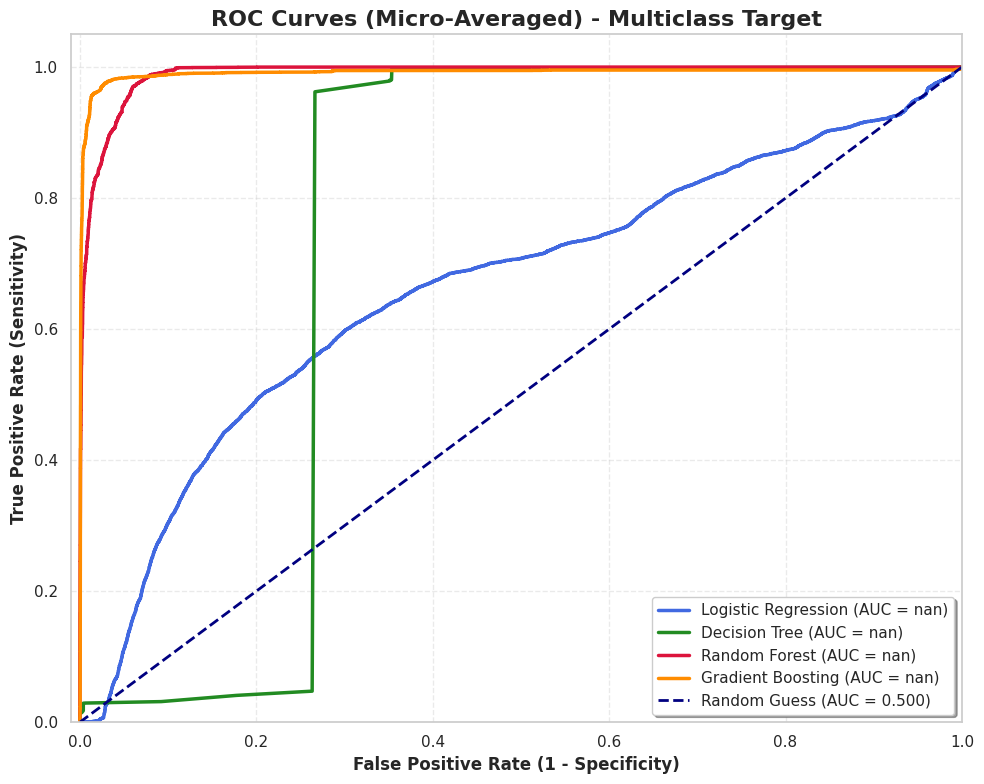

In [13]:
# =====================================================================
# PART 1: Import Necessary Libraries
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools for Data Splitting and Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder, StandardScaler, 
                                   PolynomialFeatures, FunctionTransformer, label_binarize)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_curve, auc, roc_auc_score)

import warnings
warnings.filterwarnings("ignore")

# Set visualization style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# =====================================================================
# PART 2: Data Loading & Preparation
# =====================================================================
# df = pd.read_csv("your_dataset.csv") # Uncomment and load your data

TARGET_COL = 'is_best_seller'

# CLEAN TARGET: Drop missing values to prevent false classes
df = df.dropna(subset=[TARGET_COL])

# Ensure target is treated as string to group identical boolean/text values safely
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()

# Drop text-heavy columns that require NLP, separate target
if 'Title' in df.columns:
    X = df.drop(columns=[TARGET_COL, 'Title'])
else:
    X = df.drop(columns=[TARGET_COL])

y = df[TARGET_COL]

# =====================================================================
# PART 3: Train-Test Splitting
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("="*60)
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print("="*60, "\n")

# Target Label Encoding 
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

n_classes = len(np.unique(y_train))
print(f"Number of distinct classes detected in target: {n_classes}\n")

# =====================================================================
# PART 4: Feature Engineering & Preprocessing Pipelines
# =====================================================================
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

log_transformer = FunctionTransformer(np.log1p, validate=False)

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', log_transformer), 
    ('poly_features', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# =====================================================================
# PART 5: Initialize Machine Learning Algorithms
# =====================================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
}

model_metrics = {}

# =====================================================================
# PART 6: Train, Evaluate, and Detail Accuracy
# =====================================================================
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    if n_classes == 2:
        # Binary Logic
        y_prob = model.predict_proba(X_test_processed)[:, 1] 
        roc_auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
    else:
        # Multiclass Logic (Fixed)
        y_prob = model.predict_proba(X_test_processed)
        # Force roc_auc_score to acknowledge all classes that the model trained on
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', labels=model.classes_)
        
        # Binarize with all expected classes for the ROC plot
        y_test_bin = label_binarize(y_test, classes=model.classes_)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())

    model_metrics[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"---> {name.upper()} <---")
    print(f"Accuracy Score: {acc * 100:.2f}%")
    print(f"ROC AUC Score:  {roc_auc:.4f}\n")
    
    print("Classification Report:")
    # We pass labels=model.classes_ here too just in case a class is missing in y_test
    print(classification_report(y_test, y_pred, labels=model.classes_))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    print(pd.DataFrame(cm))
    print("="*60, "\n")

# =====================================================================
# PART 7: Plot ROC Curves 
# =====================================================================
plt.figure(figsize=(10, 8))
colors = ['royalblue', 'forestgreen', 'crimson', 'darkorange']

for (name, metrics), color in zip(model_metrics.items(), colors):
    plt.plot(
        metrics['fpr'], 
        metrics['tpr'], 
        color=color, 
        lw=2.5, 
        label=f"{name} (AUC = {metrics['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')

if n_classes == 2:
    plt.title('ROC Curves - Classification Models Comparison', fontsize=16, fontweight='bold')
else:
    plt.title('ROC Curves (Micro-Averaged) - Multiclass Target', fontsize=16, fontweight='bold')

plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

## Thanks.......Please Upvote